Python     : 3.13.9
numpy      : 2.3.5
scipy      : 1.16.3
matplotlib : 3.10.6
librosa    : 0.11.0


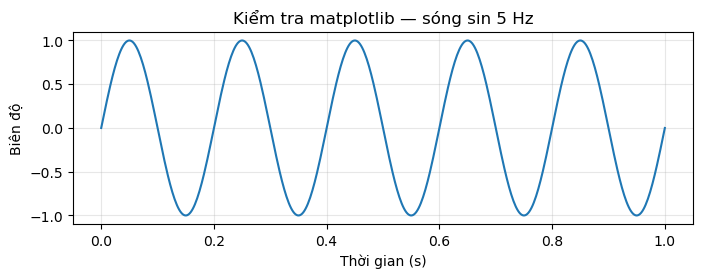

In [1]:
# Cell 1: Kiểm tra môi trường — chạy trước mọi thứ khác
import sys, numpy as np, scipy, matplotlib
import matplotlib.pyplot as plt

print(f'Python     : {sys.version.split()[0]}')
print(f'numpy      : {np.__version__}')
print(f'scipy      : {scipy.__version__}')
print(f'matplotlib : {matplotlib.__version__}')
try:
    import librosa
    print(f'librosa    : {librosa.__version__}')
except ImportError:
    print('librosa    : CHƯA cài')

# Vẽ thử sóng sin 5 Hz để xác nhận matplotlib hoạt động
t = np.linspace(0, 1, 500)
plt.figure(figsize=(8, 2.5))
plt.plot(t, np.sin(2*np.pi*5*t))
plt.title('Kiểm tra matplotlib — sóng sin 5 Hz')
plt.xlabel('Thời gian (s)'); plt.ylabel('Biên độ')
plt.grid(alpha=0.3); plt.show()


In [2]:
# ===== Cell 0: Setup chung cho Mục 5, 6, 7 =====
import numpy as np                       # thư viện số
import matplotlib.pyplot as plt          # thư viện vẽ
from scipy.io import wavfile             # đọc .wav
from scipy.signal import spectrogram     # spectrogram (STFT)
import os                                 # kiểm tra đường dẫn

# ---- Chỉnh BASE theo môi trường của bạn ----
# BASE = '/content/drive/MyDrive/XLTHS_Lab1/Datasets'   # Colab
BASE = r'D:\HocTap_PTIT\XuLyTinHieuSo\Datasets'          # Windows
# BASE = '/Users/username/XLTHS_Lab1/Datasets'        # macOS

# ---- Kiểm tra 3 file tồn tại ----
cac_file = {
    'VIVOS':        '7068130\\vivos\\train\\waves\\VIVOSSPK01\\VIVOSSPK01_R001.wav',
    'CVEAD':        'CVEAD/CVEAD_Audio_files/WAV/Happy/H10_F.wav',
    'Multilingual': 'Multilingual and Accent-Aware Transformation\\Self recordings\\Akansha Tanu\\Sample 6.mp3',
}
for ten, duongdan_con in cac_file.items():
    duongdan = os.path.join(BASE, duongdan_con)
    trang_thai = 'OK' if os.path.exists(duongdan) else 'MISSING'
    kb = os.path.getsize(duongdan)/1024 if os.path.exists(duongdan) else 0
    print(f'[{trang_thai:>7}] {ten:<14} {kb:>8.1f} KB  — {duongdan_con}')

# ---- Hàm helper: chỉ để dùng lại ở các cell sau ----
def chuan_hoa(x):
    """Đưa biên độ tín hiệu về [-1, 1]."""
    x = x.astype(np.float32)
    return x / (np.max(np.abs(x)) + 1e-9)

print()
print('Setup hoàn tất. Có thể chạy các cell sau.')


[     OK] VIVOS              93.8 KB  — 7068130\vivos\train\waves\VIVOSSPK01\VIVOSSPK01_R001.wav
[     OK] CVEAD             167.9 KB  — CVEAD/CVEAD_Audio_files/WAV/Happy/H10_F.wav
[     OK] Multilingual     7764.4 KB  — Multilingual and Accent-Aware Transformation\Self recordings\Akansha Tanu\Sample 6.mp3

Setup hoàn tất. Có thể chạy các cell sau.


In [3]:
# ===== Cell VIVOS-1: Load và xem metadata =====
duongdan_vivos = os.path.join(BASE, '7068130\\vivos\\train\\waves\\VIVOSSPK02\\VIVOSSPK02_R001.wav')
fs_v, x_v = wavfile.read(duongdan_vivos)
print(f'Đường dẫn   : {duongdan_vivos}')
print(f'fs (Hz)     : {fs_v}')
print(f'shape       : {x_v.shape}')
print(f'dtype       : {x_v.dtype}')
print(f'ndim        : {x_v.ndim}')
print(f'Độ dài (s)  : {len(x_v)/fs_v:.3f}')
print(f'min, max    : {x_v.min()}, {x_v.max()}')

# Nếu stereo (ndim=2) thì lấy kênh 0
if x_v.ndim > 1:
    x_v = x_v[:, 0]
    print('→ Stereo → đã chuyển sang kênh 0 (trái).')


Đường dẫn   : D:\HocTap_PTIT\XuLyTinHieuSo\Datasets\7068130\vivos\train\waves\VIVOSSPK02\VIVOSSPK02_R001.wav
fs (Hz)     : 16000
shape       : (66000,)
dtype       : int16
ndim        : 1
Độ dài (s)  : 4.125
min, max    : -14762, 11044


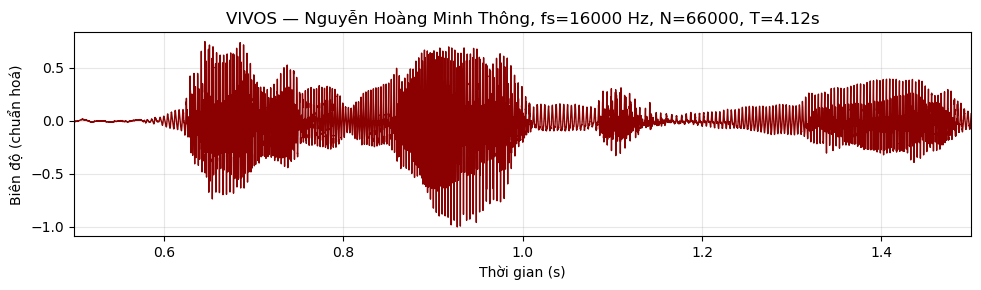

In [4]:
# ===== Cell VIVOS-2: Vẽ dạng sóng =====
x_v_norm = chuan_hoa(x_v)                  # dùng hàm helper ở Cell 0
t_v = np.arange(len(x_v_norm)) / fs_v      # trục thời gian

plt.figure(figsize=(10, 3))
plt.plot(t_v, x_v_norm, linewidth=1, color='#8B0000')
plt.xlabel('Thời gian (s)')
plt.ylabel('Biên độ (chuẩn hoá)')
plt.title(f'VIVOS — Nguyễn Hoàng Minh Thông, fs={fs_v} Hz, N={len(x_v_norm)}, T={len(x_v_norm)/fs_v:.2f}s')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xlim(0.5, 1.5)  # chỉ hiển thị đoạn 0.5s đến 1.5s
plt.show()

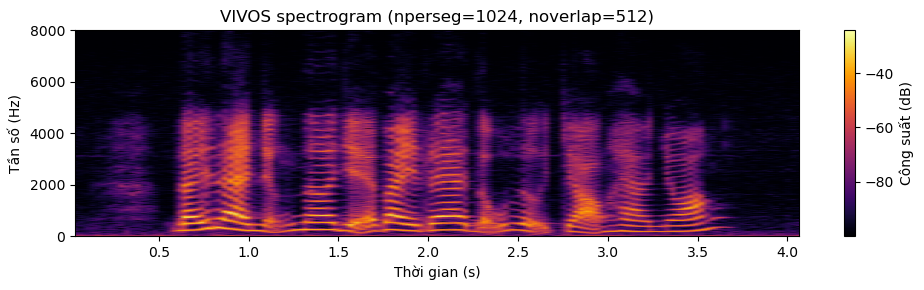

Độ phân giải tần số : Δf = fs/nperseg = 16000/1024 = 15.62 Hz
Độ phân giải thời gian: Δt = (nperseg-noverlap)/fs = 512/16000 = 32.00 ms


In [5]:
# ===== Cell VIVOS-3: Spectrogram =====
f_v, t_spec, Sxx_v = spectrogram(
    x_v_norm,
    fs=fs_v,
    nperseg=1024,        # độ dài cửa sổ (số mẫu)
    noverlap=512,       # số mẫu chồng lấn (50%)
    window='hann'       # cửa sổ Hanning
)

# 10*log10 để chuyển từ công suất sang decibel
Sxx_db = 10 * np.log10(Sxx_v + 1e-10)

plt.figure(figsize=(10, 3))
plt.pcolormesh(t_spec, f_v, Sxx_db, shading='gouraud', cmap='inferno')
plt.colorbar(label='Công suất (dB)')
plt.xlabel('Thời gian (s)')
plt.ylabel('Tần số (Hz)')
plt.title('VIVOS spectrogram (nperseg=1024, noverlap=512)')
plt.ylim(0, 8000)   # chỉ hiển thị 0–4 kHz (dải formant tiếng nói)
plt.tight_layout()
plt.show()

print(f'Độ phân giải tần số : Δf = fs/nperseg = {fs_v}/1024 = {fs_v/1024:.2f} Hz')
print(f'Độ phân giải thời gian: Δt = (nperseg-noverlap)/fs = 512/{fs_v} = {512/fs_v*1000:.2f} ms')


In [6]:
# ===== Cell CVEAD-1: Load, chuẩn hoá, thống kê =====
duongdan_c = os.path.join(BASE, r'D:\HocTap_PTIT\XuLyTinHieuSo\Datasets\CVEAD\CVEAD_Audio_files\WAV\Happy\H11_F.wav')

import librosa
x_c_goc, fs_c = librosa.load(duongdan_c, sr=None)  # sr=None giữ nguyên fs gốc, mono=True mặc định

x_c = chuan_hoa(x_c_goc)

print(f'=== CVEAD (Happy) ===')
print(f'fs         : {fs_c} Hz')
print(f'Số mẫu     : {len(x_c)}')
print(f'Độ dài     : {len(x_c)/fs_c:.3f} s')
print(f'dtype gốc  : {x_c_goc.dtype}')
print(f'--- Sau chuẩn hoá ---')
print(f'min, max   : {x_c.min():.4f}, {x_c.max():.4f}')
print(f'mean       : {x_c.mean():.4f}')
print(f'std        : {x_c.std():.4f}')
energy_h11 = np.sum(x_c**2)
P = energy_h11 / len(x_c)
print(f'công suất  : {P:.4f}')
if energy_h11 > 2001.0012:
    diff = energy_h11 - 2001.0012
    pct = diff / 2001.0012 * 100
    print(f'H11 lớn hơn H10, chênh lệch = {diff:.4f}, tương đương {pct:.2f}%')
else:
    diff = 2001.0012 - energy_h11
    pct = diff / 2001.0012 * 100
    print(f'H10 lớn hơn H11, chênh lệch = {diff:.4f}, tương đương {pct:.2f}%')

=== CVEAD (Happy) ===
fs         : 48000 Hz
Số mẫu     : 240240
Độ dài     : 5.005 s
dtype gốc  : float32
--- Sau chuẩn hoá ---
min, max   : -0.7471, 1.0000
mean       : -0.0000
std        : 0.1081
công suất  : 0.0117
H11 lớn hơn H10, chênh lệch = 805.0872, tương đương 40.23%


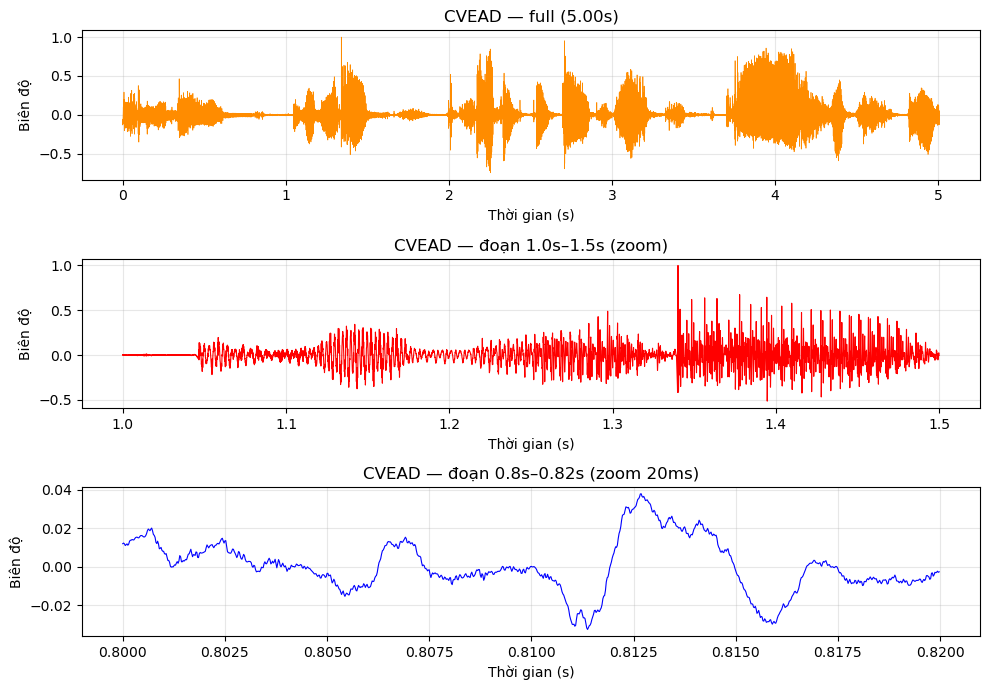

Đoạn zoom: 24000 mẫu = 0.500 s
Ước lượng chu kỳ F0 = 0.000108 s, F0 ≈ 9300.00 Hz (đếm được 186 đỉnh trong 0.020 s)


In [7]:
# ===== Cell CVEAD-2: Waveform full + waveform cắt =====
t_c = np.arange(len(x_c)) / fs_c

fig, axes = plt.subplots(3, 1, figsize=(10, 7))

# Subplot 1: full waveform
axes[0].plot(t_c, x_c, linewidth=0.5, color='darkorange')
axes[0].set_xlabel('Thời gian (s)')
axes[0].set_ylabel('Biên độ')
axes[0].set_title(f'CVEAD — full ({len(x_c)/fs_c:.2f}s)')
axes[0].grid(alpha=0.3)

# Subplot 2: cắt 1.0s đến 1.5s bằng chỉ số mẫu
i_bat_dau = int(1.0 * fs_c)   # mẫu bắt đầu 1.0 s
i_ket_thuc = int(1.5 * fs_c)  # mẫu kết thúc 1.5 s
t_cat = t_c[i_bat_dau:i_ket_thuc]
x_cat = x_c[i_bat_dau:i_ket_thuc]

axes[1].plot(t_cat, x_cat, linewidth=0.8, color='red')
axes[1].set_xlabel('Thời gian (s)')
axes[1].set_ylabel('Biên độ')
axes[1].set_title('CVEAD — đoạn 1.0s–1.5s (zoom)')
axes[1].grid(alpha=0.3)

# Subplot 3: cắt 0.8s đến 0.82s cho F0
j_bat_dau = int(0.8 * fs_c)
j_ket_thuc = int(0.82 * fs_c)
t_seg = t_c[j_bat_dau:j_ket_thuc]
x_seg = x_c[j_bat_dau:j_ket_thuc]

axes[2].plot(t_seg, x_seg, linewidth=0.8, color='blue')
axes[2].set_xlabel('Thời gian (s)')
axes[2].set_ylabel('Biên độ')
axes[2].set_title('CVEAD — đoạn 0.8s–0.82s (zoom 20ms)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Ước lượng F0 từ số đỉnh trong 20 ms
peaks = np.where((x_seg[1:-1] > x_seg[:-2]) & (x_seg[1:-1] > x_seg[2:]))[0] + 1
n_peaks = len(peaks)
segment_duration = len(x_seg) / fs_c
if n_peaks > 0:
    T0 = segment_duration / n_peaks
    F0 = n_peaks / segment_duration
    print(f'Đoạn zoom: {len(x_cat)} mẫu = {len(x_cat)/fs_c:.3f} s')
    print(f'Ước lượng chu kỳ F0 = {T0:.6f} s, F0 ≈ {F0:.2f} Hz (đếm được {n_peaks} đỉnh trong {segment_duration:.3f} s)')
else:
    print(f'Không tìm thấy đỉnh trong đoạn 0.8s–0.82s để ước lượng F0.')


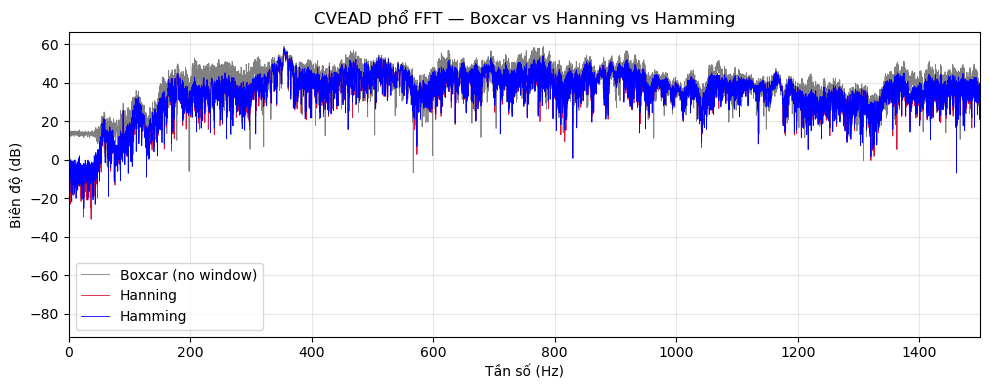

5 đỉnh mạnh nhất trong 0-1500 Hz: 355.0 Hz, 353.8 Hz, 359.6 Hz, 356.2 Hz, 358.2 Hz
Nhận xét: các đỉnh có phải là bội của F0 ≈ 9300.00 Hz


In [8]:
# ===== Cell CVEAD-3: FFT với 3 cửa sổ khác nhau =====
N_c = len(x_c)
# Tạo 3 cửa sổ
w_boxcar = np.ones(N_c)            # boxcar = không cửa sổ
w_hanning = np.hanning(N_c)        # Hanning
w_hamming = np.hamming(N_c)        # Hamming

freq_c = np.fft.rfftfreq(N_c, d=1/fs_c)    # trục tần số

X_box = np.fft.rfft(x_c * w_boxcar)
X_han = np.fft.rfft(x_c * w_hanning)
X_ham = np.fft.rfft(x_c * w_hamming)

mag_box_db = 20 * np.log10(np.abs(X_box) + 1e-10)
mag_han_db = 20 * np.log10(np.abs(X_han) + 1e-10)
mag_ham_db = 20 * np.log10(np.abs(X_ham) + 1e-10)

plt.figure(figsize=(10, 4))
plt.plot(freq_c, mag_box_db, linewidth=0.6, color='gray',    label='Boxcar (no window)')
plt.plot(freq_c, mag_han_db, linewidth=0.6, color='crimson', label='Hanning')
plt.plot(freq_c, mag_ham_db, linewidth=0.6, color='blue',    label='Hamming')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ (dB)')
plt.title('CVEAD phổ FFT — Boxcar vs Hanning vs Hamming')
plt.xlim(0, 1500)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
# Tìm 5 đỉnh mạnh nhất trong dải 0-1500 Hz
from scipy.signal import find_peaks
idx_max = np.searchsorted(freq_c, 1500, side='right')
peaks, _ = find_peaks(mag_han_db[:idx_max], distance=5)
if len(peaks) > 0:
    top5 = peaks[np.argsort(mag_han_db[peaks])][-5:][::-1]
    top5_freqs = freq_c[top5]
    print('5 đỉnh mạnh nhất trong 0-1500 Hz:', ', '.join(f'{f:.1f} Hz' for f in top5_freqs))
    if 'F0' in globals():
        harmonic = np.all(np.abs(top5_freqs / F0 - np.round(top5_freqs / F0)) < 0.1)
        print(f'Nhận xét: các đỉnh {"có" if harmonic else "không"} phải là bội của F0 ≈ {F0:.2f} Hz')
    else:
        print('Nhận xét: chưa có F0 để đối chiếu')
else:
    print('Không tìm thấy đỉnh đủ mạnh trong 0-1500 Hz để in ra.')

In [9]:
# ===== Cell ML-1: Load MP3 bằng ffmpeg trực tiếp =====
import os
import sys
import subprocess
import re
import numpy as np

# Đảm bảo static_ffmpeg được cài và thêm vào PATH
try:
    import static_ffmpeg
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'static-ffmpeg'], check=True)
    import static_ffmpeg
static_ffmpeg.add_paths()

# Tìm đường dẫn ffmpeg.exe sau khi add_paths()
ffmpeg_exe = None
for _p in os.environ['PATH'].split(os.pathsep):
    _cand = os.path.join(_p, 'ffmpeg.exe')
    if os.path.isfile(_cand):
        ffmpeg_exe = _cand
        break
if ffmpeg_exe is None:
    raise RuntimeError('Khong tim thay ffmpeg.exe sau khi static_ffmpeg.add_paths()')
print(f'Dung ffmpeg: {ffmpeg_exe}')

def _load_audio_ffmpeg(filepath, sr=None, mono=True):
    '''Đọc file audio (kể cả MP3) trực tiếp qua ffmpeg, trả về (numpy array float32, sample_rate).'''
    # Lấy thông tin file (sample rate gốc)
    probe = subprocess.run(
        [ffmpeg_exe, '-i', filepath, '-hide_banner'],
        capture_output=True, text=True
    )
    m = re.search(r'(\d+) Hz', probe.stderr)
    native_sr = int(m.group(1)) if m else 44100
    target_sr = sr if sr is not None else native_sr

    # Xuất raw PCM float32 qua pipe
    cmd = [
        ffmpeg_exe, '-i', filepath,
        '-f', 'f32le', '-acodec', 'pcm_f32le',
        '-ar', str(target_sr),
    ]
    if mono:
        cmd += ['-ac', '1']
    cmd += ['pipe:1']

    res = subprocess.run(cmd, capture_output=True)
    audio = np.frombuffer(res.stdout, dtype=np.float32)
    return audio, target_sr

# Define BASE path
BASE = r'D:\HocTap_PTIT\XuLyTinHieuSo\Datasets'

duongdan_ml = os.path.join(BASE, r'Multilingual and Accent-Aware Transformation\Self recordings\Akansha Tanu\Sample 6.mp3')

# sr=None: giữ nguyên tần số lấy mẫu gốc
# mono=True: trộn thành 1 kênh nếu file stereo
x_ml_full, fs_ml = _load_audio_ffmpeg(duongdan_ml, sr=None, mono=True)

print(f'=== Multilingual ===')
print(f'fs           : {fs_ml} Hz')
print(f'shape        : {x_ml_full.shape}')
print(f'dtype        : {x_ml_full.dtype}')
print(f'Do dai toan  : {len(x_ml_full)/fs_ml:.2f} s')
print(f'min, max     : {x_ml_full.min():.4f}, {x_ml_full.max():.4f}')

# So sánh với việc resample xuống 16kHz
x_ml_16k, _ = _load_audio_ffmpeg(duongdan_ml, sr=16000, mono=True)
print(f'Sau resample 16kHz: shape={x_ml_16k.shape}, do dai={len(x_ml_16k)/16000:.2f}s')

Dung ffmpeg: c:\Users\minht\anaconda3\Lib\site-packages\static_ffmpeg\bin\win32\ffmpeg.exe
=== Multilingual ===
fs           : 48000 Hz
shape        : (9522432,)
dtype        : float32
Do dai toan  : 198.38 s
min, max     : -1.2090, 1.3657
Sau resample 16kHz: shape=(3174144,), do dai=198.38s
